**Сбор и анализ новостных данных (NLP)**

**Устанавливливаем библиотеки:**

*newsapi-python* — инструмент для работы с API сервисом, который позволяет:
получать новости по ключевым словам, источникам, категориям; фильтровать статьи по дате публикации, языку и другим параметрам; автоматизировать сбор новостных данных для анализа.

*Natural Language Toolkit (NLTK)* — библиотека для обработки естественного языка (NLP) на Python. Позволяет: токенизировать текст (разбивать на слова/предложения); определять части речи (POS‑tagging); лемматизировать и стеммить слова; работать с корпусами текстов и словарными базами и т.д.

*tqdm* - создаёт индикаторы прогресса (прогресс‑бары) для циклов и итераций в Python. Используется при: обработке больших объёмов данных; отслеживании хода выполнения длительных операций; визуализации прогресса в консоли или Jupyter‑ноутбуке.

*VADER (Valence Aware Dictionary and sEntiment Reasoner)* — инструмент для анализа тональности (сентимент‑анализа) текстов на английском языке. Особенности: хорошо работает с короткими текстами (твиты, комментарии);учитывает эмодзи, заглавные буквы, пунктуацию и сленг; возвращает оценку тональности в виде словаря с метриками: neg — доля негативного содержания; neu — доля нейтрального содержания; pos — доля позитивного содержания; compound — итоговая оценка от −1 (очень негативно) до +1 (очень позитивно).

In [ ]:
!pip install newsapi-python
!pip install nltk
!pip install tqdm
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.5 MB/s eta 0:00:00


**Импортируем базовые библиотеки и инструменты визуализации:** import os, import re, import pandas as pd, import numpy as np, import matplotlib.pyplot as plt, import seaborn as sns.

**Библиотеки для работы с данными:** from newsapi import NewsApiClient, from tqdm import tqdm.

**Импортируем модули для обработки NLP:** import nltk, from nltk.corpus import stopwords, from nltk.stem import WordNetLemmatizer.

**Дополнительные инструменты:**
from collections import Counter — импортирует класс для подсчёта частоты встречаемости элементов в коллекции (например, слов в тексте).
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer — подключает анализатор тональности текста (сентимент‑анализ) для английского языка.
import joblib — импортирует библиотеку для сохранения и загрузки моделей машинного обучения (эффективная альтернатива pickle).

**Инструменты машинного обучения:**
*Разбивка данных и настройка моделей:*
train_test_split — разделяет данные на обучающую и тестовую выборки.
cross_val_score — выполняет кросс‑валидацию для оценки качества модели.
GridSearchCV — проводит поиск оптимальных гиперпараметров модели.

*Векторизация текста:*
TfidfVectorizer — преобразует текст в числовые векторы на основе TF‑IDF (частота термина — обратная частота документа).
CountVectorizer — создаёт векторы на основе частоты слов в тексте.

*Конвейеры и метрики:*
Pipeline — позволяет объединить предобработку и обучение модели в единый конвейер.

*Метрики качества:* accuracy_score, classification_report, confusion_matrix, roc_curve, auc — оценивают производительность классификационных моделей.

*Модели машинного обучения:*
LogisticRegression — логистическая регрессия (базовая модель классификации).
LinearSVC — линейный метод опорных векторов (SVM).
RandomForestClassifier — случайный лес (ансамбль деревьев решений).

*Вспомогательные инструменты:*
label_binarize — преобразует метки классов в бинарный формат (для многоклассовой ROC‑кривой).
resample — выполняет повторную выборку данных (например, для балансировки классов).

**Загрузка данных NLTK**

nltk.download("stopwords") — загружает список стоп‑слов для использования в NLP‑задачах.
nltk.download("wordnet") — загружает базу данных WordNet (лексическую базу для лемматизации и семантического анализа).




In [ ]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from newsapi import NewsApiClient
from tqdm import tqdm

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from collections import Counter

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample

nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
API_KEY = "e76bfca5503a4372ba2022672e31b4fc"
newsapi = NewsApiClient(api_key=API_KEY)

In [ ]:
topics = {
    "economics": "economy OR finance",
    "politics": "politics OR government",
    "business": "business OR market",
    "technology": "technology OR tech"
}

all_articles = []

for label, query in topics.items():
    print(f"\nСобираем категорию: {label}")

    response = newsapi.get_everything(
        q=query,
        language="en",
        sort_by="relevancy",
        page_size=100
    )

    articles = response.get("articles", [])
    print("Найдено:", len(articles))

    for item in articles:
        text = item.get("content") or item.get("description")
        if text:
            all_articles.append({
                "label": label,
                "text": text
            })

df = pd.DataFrame(all_articles)

print("\nДо удаления дубликатов:", df.shape)

# Удаление полных дубликатов
df.drop_duplicates(subset=["text"], inplace=True)

# Удаление слишком коротких текстов
df = df[df["text"].str.len() > 100]

print("После очистки:", df.shape)
print(df["label"].value_counts())

print("\nРазмер датасета:", df.shape)
print(df["label"].value_counts())


Собираем категорию: economics
Найдено: 98

Собираем категорию: politics
Найдено: 88

Собираем категорию: business
Найдено: 88

Собираем категорию: technology
Найдено: 88

До удаления дубликатов: (362, 2)
После очистки: (325, 2)
label
economics     88
politics      83
business      81
technology    73
Name: count, dtype: int64

Размер датасета: (325, 2)
label
economics     88
politics      83
business      81
technology    73
Name: count, dtype: int64


**Визуализация распределения классов**

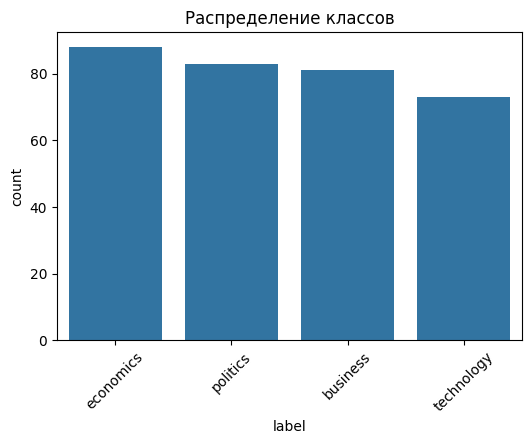

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["label"])
plt.title("Распределение классов")
plt.xticks(rotation=45)
plt.show()

**Предобработка текста**

100%|██████████| 325/325 [00:04<00:00, 76.24it/s]


sentiment_label
positive    153
neutral      89
negative     83
Name: count, dtype: int64


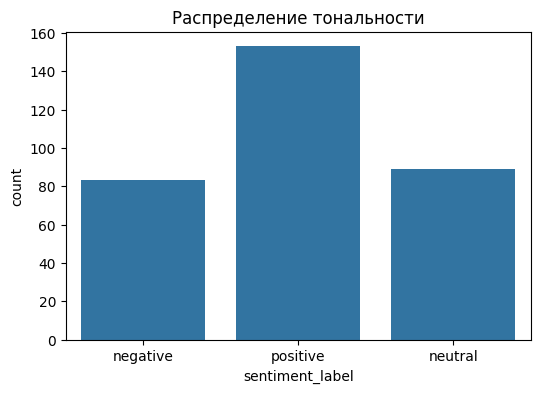

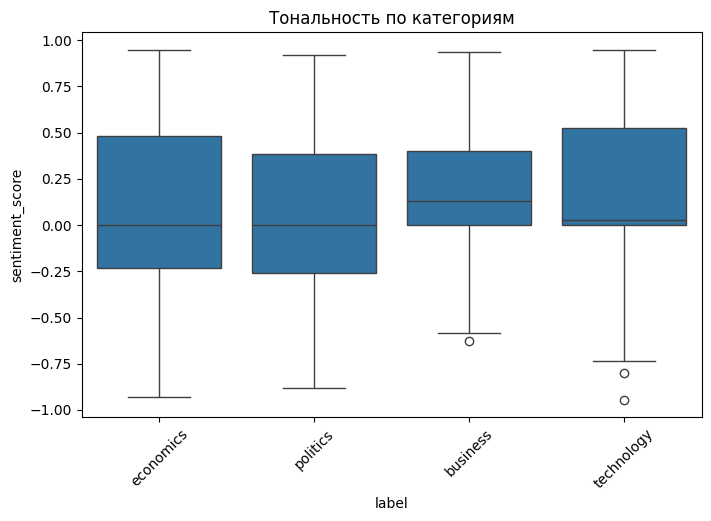

In [ ]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = re.sub(r'<.*?>', ' ', str(text))
    text = re.sub(r'[^a-zA-Z ]', ' ', text).lower()
    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(w)
        for w in tokens
        if w not in stop_words and len(w) > 2
    ]
    return " ".join(tokens)

tqdm.pandas()
df["clean_text"] = df["text"].progress_apply(preprocess_text)
# --- Анализ тональности ---
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(text)
    return score["compound"]

df["sentiment_score"] = df["text"].apply(get_sentiment)

# Классификация тональности
def sentiment_label(score):
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

df["sentiment_label"] = df["sentiment_score"].apply(sentiment_label)

print(df["sentiment_label"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x=df["sentiment_label"])
plt.title("Распределение тональности")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x="label", y="sentiment_score", data=df)
plt.title("Тональность по категориям")
plt.xticks(rotation=45)
plt.show()

**Анализ по категориям:**

*Economics и Politics*: медиана близка к 0 — преобладает нейтральная тональность;
распределение достаточно сбалансировано (усы симметричны); нет явных выбросов.

Слегка позитивная тональность *Business и Technology*: медианы выше 0 указывают на преобладание умеренно позитивных оценок.
Выбросы в Business и Technology: наличие отрицательных выбросов говорит о том, что, несмотря на в целом позитивную картину, есть темы/аспекты, вызывающие резкое недовольство.
Разброс значений: Economics и Politics характеризуются наибольшим разбросом оценок, что может свидетельствовать о высокой полярности мнений в этих категориях.


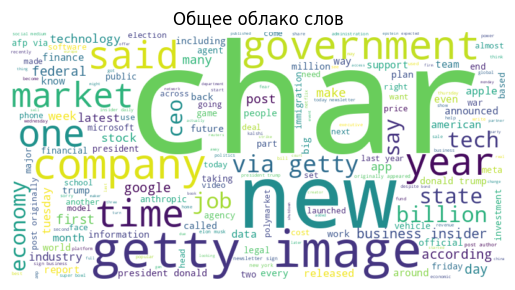

In [ ]:
from wordcloud import WordCloud

text = " ".join(df["clean_text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Общее облако слов")
plt.show()

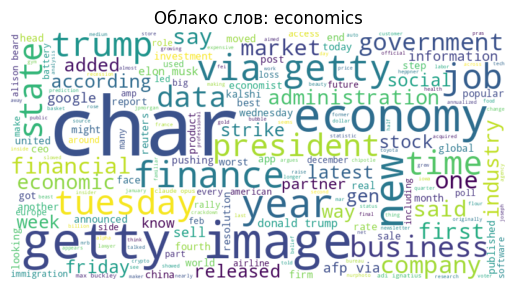

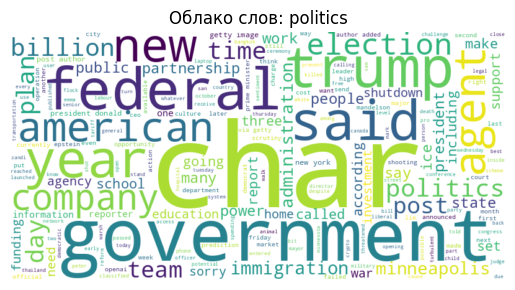

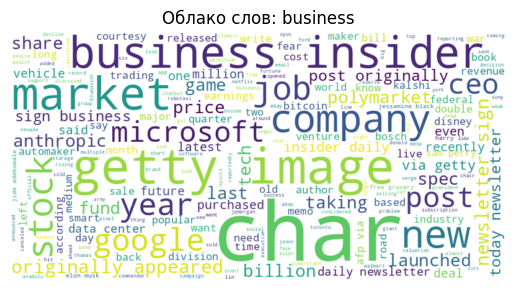

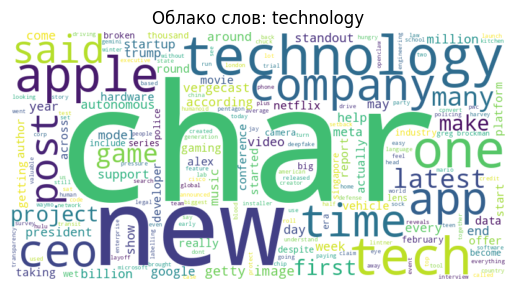

In [ ]:
for category in df["label"].unique():
    text = " ".join(df[df["label"] == category]["clean_text"])

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate(text)

    plt.figure()
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Облако слов: {category}")
    plt.show()

**Анализ частоты слов**

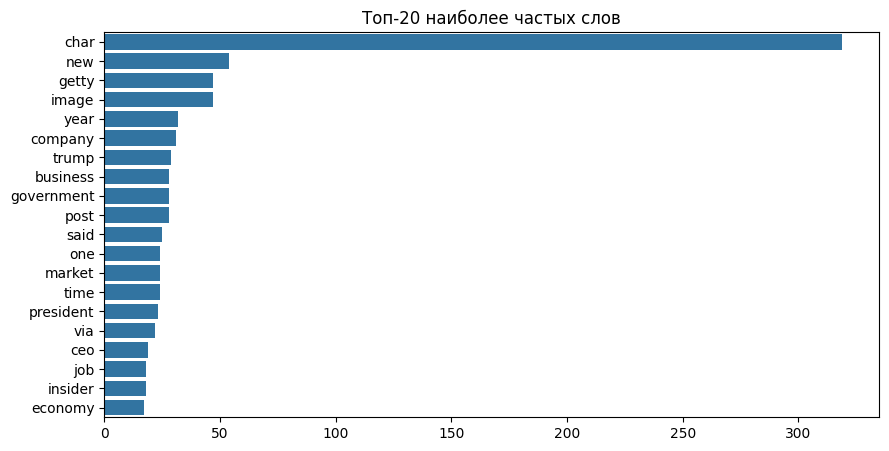

In [ ]:
all_words = " ".join(df["clean_text"]).split()
word_freq = Counter(all_words).most_common(20)

words = [w[0] for w in word_freq]
counts = [w[1] for w in word_freq]

plt.figure(figsize=(10,5))
sns.barplot(x=counts, y=words)
plt.title("Топ-20 наиболее частых слов")
plt.show()

**Анализ биграмм (пары последовательно идущих слов)**

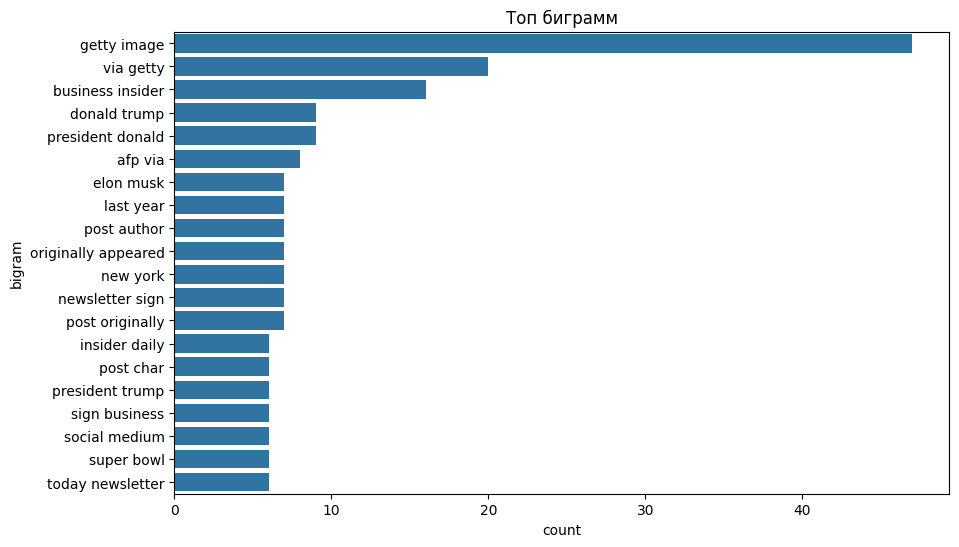

In [ ]:
bigram_vectorizer = CountVectorizer(ngram_range=(2,2), max_features=20)
X_bigrams = bigram_vectorizer.fit_transform(df["clean_text"])

bigram_counts = np.sum(X_bigrams.toarray(), axis=0)
bigram_names = bigram_vectorizer.get_feature_names_out()

bigram_df = pd.DataFrame({
    "bigram": bigram_names,
    "count": bigram_counts
}).sort_values(by="count", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=bigram_df, x="count", y="bigram")
plt.title("Топ биграмм")
plt.show()

**Балансировка классов**

Позволяет сделать количество примеров для каждого класса одиноковым. Это необходимо сделать для машинного обучения, т.к. позволяет избежать разбалансировки в сторону большинства.

In [ ]:
df_balanced = []

for label in df["label"].unique():
    df_class = df[df["label"] == label]
    df_resampled = resample(
        df_class,
        replace=True,
        n_samples=df["label"].value_counts().max(),
        random_state=42
    )
    df_balanced.append(df_resampled)

df = pd.concat(df_balanced)

print("После балансировки:")
print(df["label"].value_counts())

После балансировки:
label
economics     88
politics      88
business      88
technology    88
Name: count, dtype: int64


**Рсапределяем данные на обучающую и тестовую выборки**

In [ ]:
X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Построение моделей**

In [ ]:
models = {
    "Logistic Regression": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=7000, ngram_range=(1,2))),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]),

    "Linear SVM": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=7000, ngram_range=(1,2))),
        ("model", LinearSVC(class_weight="balanced"))
    ]),

    "Random Forest": Pipeline([
        ("tfidf", TfidfVectorizer(max_features=7000, ngram_range=(1,2))),
        ("model", RandomForestClassifier(class_weight="balanced"))
    ])
}

**Кросс-валидация**

Создаем словарь моделей машинного обучения для классификации текстов.

Используем переменную models — словарь Python, где:

ключи — читаемые названия моделей ("Logistic Regression", "Linear SVM", "Random Forest");

значения — объекты Pipeline из библиотеки scikit‑learn, объединяющие два этапа:

Векторизацию текста (TfidfVectorizer).

Классификацию (LogisticRegression, LinearSVC или RandomForestClassifier).

Компоненты конвейера
1. TfidfVectorizer (одинаковый для всех моделей):

max_features=7000 — ограничивает словарь до 7 000 самых частых токенов (слов и биграмм), что снижает размерность данных и ускоряет обучение.

ngram_range=(1,2) — учитывает не только отдельные слова (униграммы), но и пары слов (биграммы). Например, для фразы «искусственный интеллект» будут признаки: искусственный, интеллект, искусственный интеллект.

Результат: преобразует сырой текст в числовые векторы на основе TF‑IDF (Term Frequency‑Inverse Document Frequency) — чем уникальнее и важнее слово для документа, тем выше его вес.

2. Классификаторы (разные для каждой модели):

Logistic Regression (LogisticRegression):
max_iter=1000 — увеличивает максимальное число итераций до 1 000 (по умолчанию часто 100), чтобы алгоритм гарантированно сошёлся.
class_weight="balanced" — автоматически корректирует веса классов, чтобы уравновесить влияние редких и частых классов (полезно при дисбалансе меток).

Linear SVM (LinearSVC):
class_weight="balanced" — аналогично логистической регрессии, учитывает дисбаланс классов.
Линейный SVM хорошо работает с разреженными текстовыми данными и часто даёт высокую точность.

Random Forest (RandomForestClassifier):
class_weight="balanced" — балансирует важность классов при построении деревьев.
Ансамбль деревьев решений устойчив к переобучению и не требует сильной нормализации признаков.

**Выбираем лучшую модель**

In [ ]:
results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    results[name] = scores.mean()
    print(f"{name}: {scores.mean():.4f}")

Logistic Regression: 0.6939
Linear SVM: 0.6867
Random Forest: 0.6867


**Визуализация сравнения моделей**

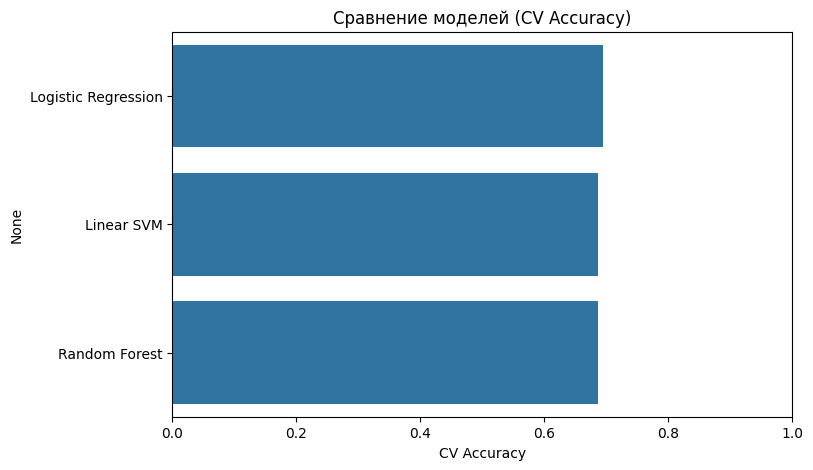

In [ ]:
results_df = pd.DataFrame.from_dict(
    results,
    orient="index",
    columns=["CV Accuracy"]
).sort_values(by="CV Accuracy", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=results_df["CV Accuracy"], y=results_df.index)
plt.title("Сравнение моделей (CV Accuracy)")
plt.xlim(0,1)
plt.show()

**Обучение лучшей модели**

In [ ]:
best_model_name = max(results, key=results.get)
print("Лучшая модель:", best_model_name)

best_model = models[best_model_name]
best_model.fit(X_train, y_train)

# Сохранение модели
joblib.dump(best_model, "best_news_classifier.pkl")
print("Модель сохранена в файл best_news_classifier.pkl")

y_pred = best_model.predict(X_test)

Лучшая модель: Logistic Regression
Модель сохранена в файл best_news_classifier.pkl


**Оценка качества**

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.676056338028169
              precision    recall  f1-score   support

    business       0.75      0.67      0.71        18
   economics       0.67      0.59      0.62        17
    politics       0.81      0.72      0.76        18
  technology       0.54      0.72      0.62        18

    accuracy                           0.68        71
   macro avg       0.69      0.67      0.68        71
weighted avg       0.69      0.68      0.68        71



**Вывод**

*Precision (точность)* — доля верно предсказанных примеров среди всех предсказаний для категории.
*Recall (полнота)* — доля верно предсказанных примеров среди всех примеров категории в тестовом наборе.
*F1-score* — гармоническое среднее между точностью и полнотой (баланс между ними).
*Support* — количество примеров каждой категории в тестовом наборе.
Результаты по категориям:

Business: точность — 0.75, полнота — 0.67, F1-score — 0.71 (18 примеров).
Economics: точность — 0.67, полнота — 0.59, F1-score — 0.62 (17 примеров).
Politics: точность — 0.81, полнота — 0.72, F1-score — 0.76 (18 примеров).
Technology: точность — 0.54, полнота — 0.72, F1-score — 0.62 (18 примеров).

Общие метрики:

Macro avg (среднее по категориям): точность — 0.69, полнота — 0.67, F1-score — 0.68.
Weighted avg (взвешенное среднее): точность — 0.69, полнота — 0.68, F1-score — 0.68 (учитывает количество примеров в каждой категории).

*Вывод*

**Лучшая модель — Logistic Regression.**

**Общая точность классификации — ~67.6%.**

**Модель лучше всего справляется с категорией Politics (F1-score = 0.76).**

Слабее всего — с категорией Technology (точность = 0.54).

**Confusion Matrix (матрица ошибок)**

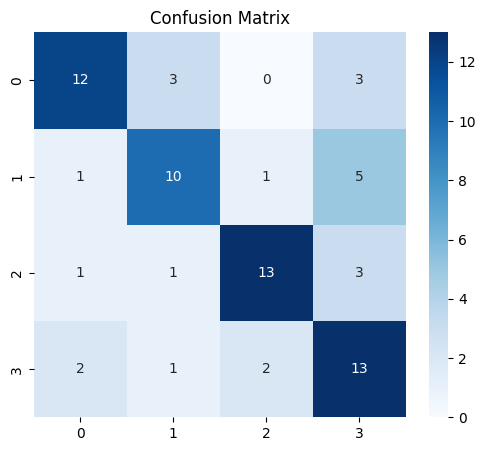

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

Истинные классы:

Класс 0: 12 примеров верно классифицированы, 3 отнесены к классу 1, 3 — к классу 3.
Класс 1: 10 верно классифицированы, 1 отнесён к классу 0, 1 — к классу 2, 5 — к классу 3.
Класс 2: 13 верно классифицированы, 1 отнесён к классу 0, 1 — к классу 1, 3 — к классу 3.
Класс 3: 13 верно классифицированы, 2 отнесены к классу 0, 1 — к классу 1, 2 — к классу 2.
Диагональные элементы (верно предсказанные случаи): 12 + 10 + 13 + 13 = 48 (корректные предсказания).

Недиагональные элементы (ошибки): сумма всех остальных значений = 19 (некорректные предсказания).

Выводы
Общая точность (accuracy):
(48 / (48 + 19)) ≈ 72% — модель верно классифицирует около 72% примеров.

Сильные стороны модели:

Высокая точность для классов 2 и 3 (13 верных предсказаний из ~16–17 примеров).
Класс 1 также показывает неплохой результат (10 верных из ~17).
Проблемные места:

Класс 0 имеет относительно много ошибок (6 из 18 примеров отнесены к другим классам).
Частые ошибки:
Класс 0 путается с классами 1 и 3.
Класс 1 иногда ошибочно классифицируется как 3.
Класс 3 иногда путается с классами 0 и 2.

Можно рекомендовать:

Переобучение модели с другими гиперпараметрами или архитектурой.
Анализ ошибочных предсказаний (например, изучение текстов/примеров, где класс 0 ошибочно отнесён к 3).
Балансировка классов, если распределение неравномерное.
Использование метрик помимо accuracy: precision, recall, F1-score для каждого класса (особенно если классы несбалансированы).
Визуализация:
Тепловая карта помогает быстро выявить «горячие точки» ошибок (ячейки с высокими значениями вне диагонали).

Итог: код эффективно визуализирует качество классификации, показывая, где модель сильна, а где допускает ошибки. Это ключевой инструмент для диагностики и улучшения моделей машинного обучения.

**Анализ качества многоклассовой модели классификации с помощью ROC-AUC**

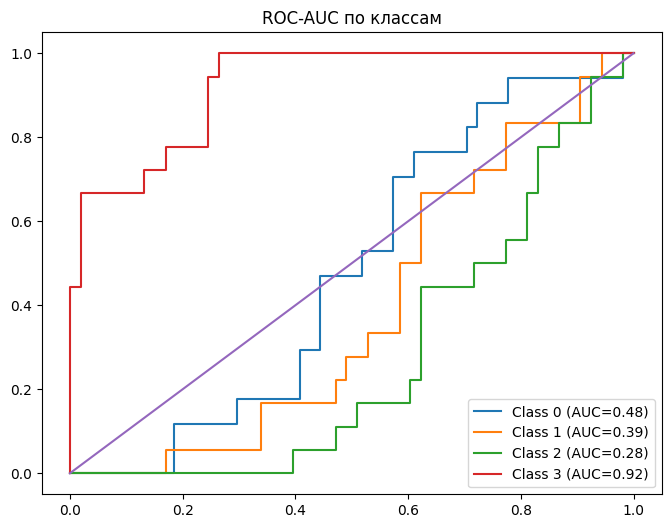

In [ ]:
y_test_bin = label_binarize(y_test, classes=y.unique())
n_classes = y_test_bin.shape[1]

if hasattr(best_model.named_steps["model"], "decision_function"):
    y_score = best_model.decision_function(X_test)
else:
    y_score = best_model.predict_proba(X_test)

plt.figure(figsize=(8,6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1])
plt.title("ROC-AUC по классам")
plt.legend()
plt.show()

**Выводы по модели**

ROC-AUC по классам:

Class 0: AUC = 0.48
Class 1: AUC = 0.39
Class 2: AUC = 0.28
Class 3: AUC = 0.92

Интерпретация AUC:

AUC ≈ 1: идеальная классификация (модель отлично различает классы).

AUC ≈ 0.5: модель работает как случайное угадывание (диагональ на графике).

AUC < 0.5: модель хуже случайного угадывания (кривая ниже диагонали).


*Анализ результатов:*

Класс 3 — лучшая классификация (AUC = 0.92). Модель почти идеально распознаёт этот класс, кривая ROC близка к верхнему левому углу.
Классы 0 и 1 — среднее качество (AUC ≈ 0.48–0.39). Модель слабо различает эти классы, кривые ROC заметно ниже диагонали.
Класс 2 — наихудшая классификация (AUC = 0.28). Модель существенно хуже случайного угадывания, кривая ROC сильно опущена.


Выводы и рекомендации:

Неравномерность качества: модель значительно лучше распознаёт некоторые классы (например, 3), чем другие (например, 2). Это может быть связано с дисбалансом данных или сложностью разделения классов.

Необходимость балансировки данных: если классы несбалансированы, стоит применить методы взвешивания (class_weight="balanced") или техники oversampling/undersampling.

Оптимизация для слабых классов: для классов с низким AUC (0, 1, 2) можно:
добавить больше обучающих примеров;
использовать другие алгоритмы или гиперпараметры;
применить ансамблевые методы.

Пересмотр признаков: возможно, текущие признаки недостаточно информативны для разделения сложных классов. Стоит добавить новые признаки или провести отбор признаков (Feature Selection).

Комбинированная метрика: хотя AUC для класса 3 высокий, общий результат модели слабый из-за низких значений для других классов. Рекомендуется использовать макро- или микро-среднее AUC для оценки общего качества.


Итог: код наглядно демонстрирует слабые и сильные стороны модели через ROC-AUC анализ. Основной акцент при доработке модели следует сделать на улучшении классификации для классов 0, 1 и особенно 2.

**Общий вывод по работе:**

Указанный код охватывает полный цикл обработки новостных данных методом NLP: автоматизированный сбор, очистку, анализ тональности, исследовательскую аналитику и построение многоклассовой модели классификации.


Наилучший результат показала модель Logistic Regression с точностью около 70%, что подтверждает применимость классических линейных алгоритмов для задач текстовой классификации.
